# Отбор признаков и настройка CatBoost

Этот этап выполняется после базовых экспериментов. Важность признаков анализируется по сохранённым моделям всех трёх временных разбиений. Параметры CatBoost сравниваются по первым двум периодам; метрика третьего периода приводится как дополнительная диагностика, но не считается полностью независимой оценкой после отбора признаков.

In [1]:
import json
import sys
from dataclasses import asdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from artifacts import config_hash, configure_logging, save_json
from config import ARTIFACT_DIR, REPORT_DIR, ExperimentConfig
from data import load_metadata, load_or_prepare_events
from experiments import run_time_cv
from feature_sets import load_behavior_feature_sets
from selected_features import (
    COMPACT_BEHAVIOR_COLUMNS_V1,
    DOMAIN_NUMERIC_COLUMNS,
    RANKED_NUMERIC_COLUMNS,
    STABLE_CATEGORICAL_COLUMNS,
)

configure_logging()
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")
SELECTION_DIR = ARTIFACT_DIR / "feature_selection"
TABLE_DIR = REPORT_DIR / "tables"
FIGURE_DIR = REPORT_DIR / "figures" / "feature_importance"
SELECTION_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

c:\Users\Kolya\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Данные и полный набор кандидатов

In [2]:
data = load_metadata()
events = load_or_prepare_events(data.metadata)
behavior_sets = load_behavior_feature_sets(
    data.metadata,
    data.train,
    events,
)
extended_behavior = behavior_sets["extended_behavior"]
pd.Series({
    "rows": len(extended_behavior),
    "features": extended_behavior.shape[1] - 1,
}).to_frame("value")

16:28:55 | INFO | data | Метаданные загружены: train=11091, test=4909, ботов=899
16:28:56 | INFO | artifacts | События внутри окон: кеш, строк=288126, колонок=18
16:28:56 | INFO | feature_sets | Поведенческие наборы загружены из кеша


,value
rows,16000
features,1020


## Важность признаков полного CatBoost

Используем уже сохранённую важность из базового эксперимента `catboost_extended_behavior`. Если файла нет, сначала нужно полностью выполнить `base_experiments.ipynb`.

In [3]:
importance_paths = list(
    (ARTIFACT_DIR / "experiments" / "catboost_extended_behavior").glob(
        "*/feature_importance.csv"
    )
)
if len(importance_paths) != 1:
    raise FileNotFoundError(
        "Ожидался один завершённый запуск catboost_extended_behavior"
    )
full_importance = pd.read_csv(importance_paths[0])
required_columns = {"feature", "fold_01", "fold_02", "fold_03"}
if not required_columns.issubset(full_importance.columns):
    raise ValueError("В таблице важности отсутствуют временные разбиения")
full_importance.head(30)

,feature,fold_01,fold_02,fold_03,mean_importance,min_importance
0,pointer_move_mean,1.667238,2.497350,2.951552,2.372047,1.667238
1,events_per_active_minute,3.002765,1.549568,2.452743,2.335026,1.549568
2,session_15m_span_max,1.981210,1.875047,1.423433,1.759897,1.423433
3,interval_positive_min,1.979442,1.591855,1.662781,1.744692,1.591855
4,pointer_x_std,2.057461,1.641879,1.370486,1.689942,1.370486
5,interval_share_le_60s,0.377943,1.526393,2.791541,1.565292,0.377943
6,pointer_y_std,1.809316,1.636235,1.231028,1.558859,1.231028
7,fast_run_le_30s,1.584325,1.572596,1.483382,1.546768,1.483382
8,pointer_zero_share,1.730742,1.511248,1.283122,1.508371,1.283122
9,session_30m_span_mean,1.407579,1.212779,1.239932,1.286763,1.212779


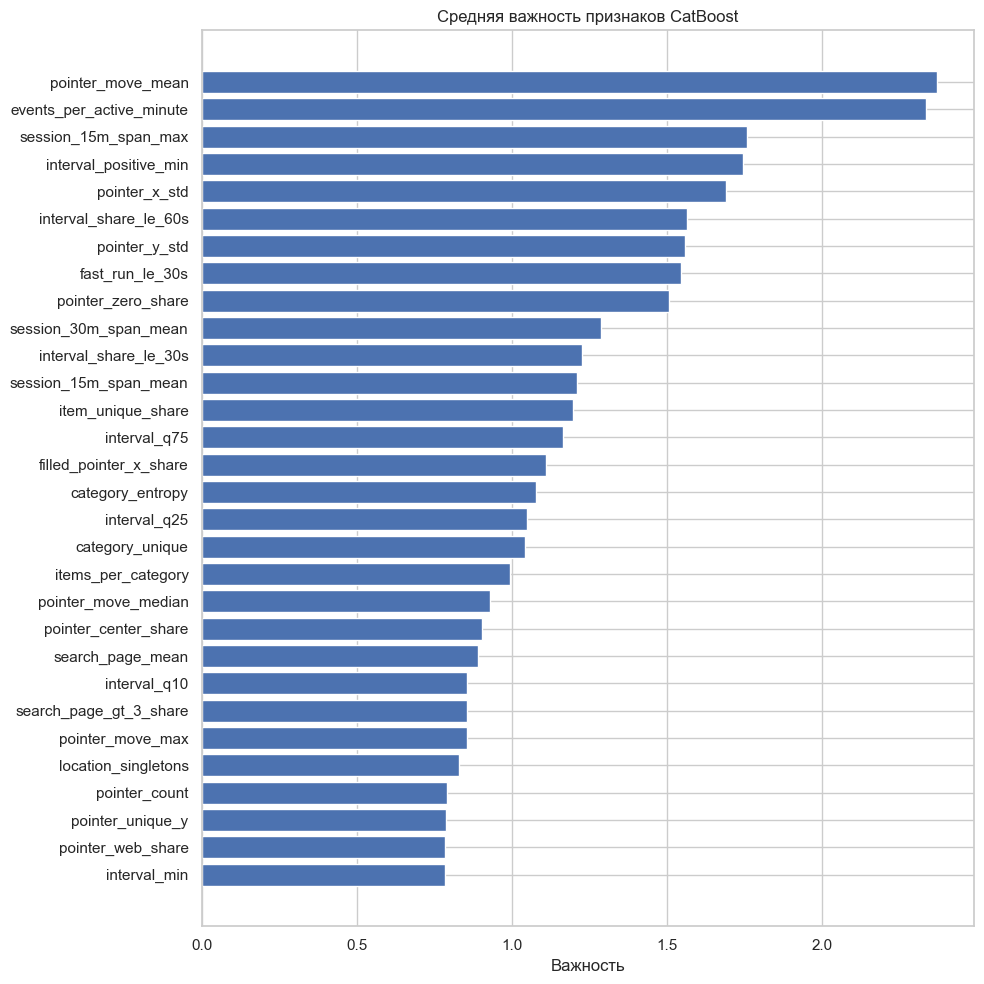

In [4]:
importance_plot = full_importance.head(30).sort_values("mean_importance")
fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(importance_plot["feature"], importance_plot["mean_importance"])
ax.set_title("Средняя важность признаков CatBoost")
ax.set_xlabel("Важность")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "extended_behavior_top30.png", dpi=160, bbox_inches="tight")
plt.show()

## Правило отбора

Точный список перенесён из исследовательского прогона и зафиксирован в `src/selected_features.py`. В него входят числовые признаки, устойчиво важные на временных разбиениях, содержательные признаки, которые хотелось сохранить независимо от ранга, и восемь категориальных признаков. Ни исходные идентификаторы, ни даты в список не входят.

In [5]:
compact_columns = list(COMPACT_BEHAVIOR_COLUMNS_V1)
selected_numeric = full_importance.loc[
    full_importance["feature"].isin(
        list(RANKED_NUMERIC_COLUMNS) + list(DOMAIN_NUMERIC_COLUMNS)
    )
].copy()
selected_numeric["selection_group"] = selected_numeric["feature"].map(
    lambda feature: "importance" if feature in RANKED_NUMERIC_COLUMNS else "domain"
)

missing = [column for column in compact_columns if column not in extended_behavior.columns]
if missing:
    raise ValueError("В полном наборе нет колонок: " + ", ".join(missing))
save_json(compact_columns, SELECTION_DIR / "compact_behavior_columns.json")
selected_numeric.to_csv(SELECTION_DIR / "compact_behavior_selection.csv", index=False)
pd.Series({
    "by_importance": len(RANKED_NUMERIC_COLUMNS),
    "domain": len(DOMAIN_NUMERIC_COLUMNS),
    "categorical": len(STABLE_CATEGORICAL_COLUMNS),
    "total": len(compact_columns),
}).to_frame("count")

,count
by_importance,40
domain,12
categorical,8
total,60


## Проверка компактного набора

In [6]:
compact_behavior = extended_behavior[["cookie_id"] + compact_columns].copy()
compact_config = ExperimentConfig(
    name="catboost_compact_behavior",
    feature_set="compact_behavior",
    model_name="catboost",
    frequency_feature_style="prefix",
    expected_feature_count=66,
    feature_version="compact_behavior_v1",
    compute_mode="cpu",
)
compact_result = run_time_cv(
    compact_config,
    compact_behavior,
    data.train,
    events=events,
)
pd.Series(compact_result).to_frame("value")

16:28:57 | INFO | experiments | catboost_compact_behavior: модель=catboost, набор=compact_behavior, признаков до истории=60


16:28:57 | INFO | validation | fold_01: train=5930, valid=1669, valid_bots=123


0:	test: 0.7773062	best: 0.7773062 (0)	total: 158ms	remaining: 2m 37s
100:	test: 0.9271974	best: 0.9273762 (99)	total: 6.59s	remaining: 58.7s
200:	test: 0.9360006	best: 0.9360742 (199)	total: 12s	remaining: 47.8s
300:	test: 0.9395503	best: 0.9398395 (291)	total: 17.6s	remaining: 40.9s
400:	test: 0.9412699	best: 0.9415907 (370)	total: 24.3s	remaining: 36.3s
500:	test: 0.9427003	best: 0.9427003 (500)	total: 31.4s	remaining: 31.2s
600:	test: 0.9433419	best: 0.9436889 (591)	total: 38.4s	remaining: 25.5s
700:	test: 0.9435890	best: 0.9441202 (637)	total: 47.7s	remaining: 20.4s
800:	test: 0.9433050	best: 0.9441202 (637)	total: 56.1s	remaining: 13.9s
900:	test: 0.9432051	best: 0.9441202 (637)	total: 1m 5s	remaining: 7.17s


16:30:10 | INFO | experiments | catboost_compact_behavior | fold_01 | P@R70=0.6541 | AP=0.7763 | ROC-AUC=0.9434 | 73.4 с


999:	test: 0.9434155	best: 0.9441202 (637)	total: 1m 13s	remaining: 0us

bestTest = 0.9441201527
bestIteration = 637



...

999:	test: 0.9389322	best: 0.9473333 (256)	total: 1m 13s	remaining: 0us

bestTest = 0.9473333333
bestIteration = 256

0:	test: 0.7934516	best: 0.7934516 (0)	total: 60.3ms	remaining: 1m
100:	test: 0.9353085	best: 0.9353085 (100)	total: 8.34s	remaining: 1m 14s
200:	test: 0.9345059	best: 0.9353818 (102)	total: 16.1s	remaining: 1m 4s
300:	test: 0.9375768	best: 0.9375768 (300)	total: 22.1s	remaining: 51.3s
400:	test: 0.9364845	best: 0.9376082 (303)	total: 27.7s	remaining: 41.4s
500:	test: 0.9356330	best: 0.9376082 (303)	total: 33.6s	remaining: 33.5s
600:	test: 0.9337870	best: 0.9376082 (303)	total: 39.4s	remaining: 26.2s
700:	test: 0.9331449	best: 0.9376082 (303)	total: 45.5s	remaining: 19.4s
800:	test: 0.9332845	best: 0.9376082 (303)	total: 53.5s	remaining: 13.3s
900:	test: 0.9333613	best: 0.9376082 (303)	total: 1m 2s	remaining: 6.92s


16:32:35 | INFO | experiments | catboost_compact_behavior | fold_03 | P@R70=0.6474 | AP=0.7597 | ROC-AUC=0.9322 | 71.2 с


999:	test: 0.9322376	best: 0.9376082 (303)	total: 1m 10s	remaining: 0us

bestTest = 0.9376081798
bestIteration = 303



16:32:35 | INFO | experiments | catboost_compact_behavior завершён: mean P@R70=0.6544, last=0.6474


,value
experiment,catboost_compact_behavior
feature_set,compact_behavior
model,catboost
feature_count,66
total_fit_seconds,218.121821
mean_precision_at_recall_70,0.654396
std_precision_at_recall_70,0.005823
last_fold_precision_at_recall_70,0.647399
mean_average_precision,0.766314
mean_roc_auc,0.938195


## Результаты подбора параметров

Полный перебор не повторяется: ниже перенесены результаты предыдущего запуска на том же компактном наборе и тех же первых двух временных разбиениях. Было завершено 15 из 16 конфигураций. Вариант с глубиной 9 и 1 500 деревьями не успел завершиться; запускать его отдельно нет необходимости, поскольку увеличение числа деревьев при глубине 9 уже не давало устойчивого улучшения.

In [7]:
grid_results = pd.DataFrame([
    {"depth": 3, "iterations": 300,  "mean_precision_at_recall_70": 0.6032, "std_precision_at_recall_70": 0.0345, "mean_average_precision": 0.7547, "mean_roc_auc": 0.9336},
    {"depth": 3, "iterations": 700,  "mean_precision_at_recall_70": 0.7088, "std_precision_at_recall_70": 0.0370, "mean_average_precision": 0.7859, "mean_roc_auc": 0.9434},
    {"depth": 3, "iterations": 1200, "mean_precision_at_recall_70": 0.7265, "std_precision_at_recall_70": 0.0192, "mean_average_precision": 0.7883, "mean_roc_auc": 0.9435},
    {"depth": 3, "iterations": 1500, "mean_precision_at_recall_70": 0.7188, "std_precision_at_recall_70": 0.0228, "mean_average_precision": 0.7872, "mean_roc_auc": 0.9432},
    {"depth": 5, "iterations": 300,  "mean_precision_at_recall_70": 0.7089, "std_precision_at_recall_70": 0.0184, "mean_average_precision": 0.7674, "mean_roc_auc": 0.9339},
    {"depth": 5, "iterations": 700,  "mean_precision_at_recall_70": 0.7098, "std_precision_at_recall_70": 0.0138, "mean_average_precision": 0.7932, "mean_roc_auc": 0.9482},
    {"depth": 5, "iterations": 1200, "mean_precision_at_recall_70": 0.7137, "std_precision_at_recall_70": 0.0006, "mean_average_precision": 0.7902, "mean_roc_auc": 0.9464},
    {"depth": 5, "iterations": 1500, "mean_precision_at_recall_70": 0.7143, "std_precision_at_recall_70": 0.0012, "mean_average_precision": 0.7897, "mean_roc_auc": 0.9453},
    {"depth": 7, "iterations": 300,  "mean_precision_at_recall_70": 0.6810, "std_precision_at_recall_70": 0.0065, "mean_average_precision": 0.7694, "mean_roc_auc": 0.9383},
    {"depth": 7, "iterations": 700,  "mean_precision_at_recall_70": 0.7188, "std_precision_at_recall_70": 0.0092, "mean_average_precision": 0.7913, "mean_roc_auc": 0.9459},
    {"depth": 7, "iterations": 1200, "mean_precision_at_recall_70": 0.7206, "std_precision_at_recall_70": 0.0189, "mean_average_precision": 0.7876, "mean_roc_auc": 0.9433},
    {"depth": 7, "iterations": 1500, "mean_precision_at_recall_70": 0.7159, "std_precision_at_recall_70": 0.0362, "mean_average_precision": 0.7830, "mean_roc_auc": 0.9413},
    {"depth": 9, "iterations": 300,  "mean_precision_at_recall_70": 0.6581, "std_precision_at_recall_70": 0.0111, "mean_average_precision": 0.7538, "mean_roc_auc": 0.9361},
    {"depth": 9, "iterations": 700,  "mean_precision_at_recall_70": 0.7128, "std_precision_at_recall_70": 0.0168, "mean_average_precision": 0.7860, "mean_roc_auc": 0.9460},
    {"depth": 9, "iterations": 1200, "mean_precision_at_recall_70": 0.7221, "std_precision_at_recall_70": 0.0237, "mean_average_precision": 0.7813, "mean_roc_auc": 0.9444},
])
grid_results = grid_results.sort_values(
    "mean_precision_at_recall_70",
    ascending=False,
).reset_index(drop=True)
grid_results.to_csv(TABLE_DIR / "catboost_grid_previous_run.csv", index=False)
grid_results

,depth,iterations,mean_precision_at_recall_70,std_precision_at_recall_70,mean_average_precision,mean_roc_auc
0,3,1200,0.7265,0.0192,0.7883,0.9435
1,9,1200,0.7221,0.0237,0.7813,0.9444
2,7,1200,0.7206,0.0189,0.7876,0.9433
3,3,1500,0.7188,0.0228,0.7872,0.9432
4,7,700,0.7188,0.0092,0.7913,0.9459
5,7,1500,0.7159,0.0362,0.7830,0.9413
6,5,1500,0.7143,0.0012,0.7897,0.9453
7,5,1200,0.7137,0.0006,0.7902,0.9464
8,9,700,0.7128,0.0168,0.7860,0.9460
9,5,700,0.7098,0.0138,0.7932,0.9482


In [8]:
# Код исходного перебора оставлен для воспроизводимости, но при Run All
# он не выполняется. При необходимости этот блок можно вернуть отдельно.
#
# grid_results = []
# for params in grid_plan.to_dict(orient="records"):
#     config = ExperimentConfig(
#         name=f"catboost_compact_depth{params['depth']}_trees{params['iterations']}",
#         feature_set="compact_behavior",
#         model_name="catboost",
#         model_params=params,
#         fold_names=("fold_01", "fold_02"),
#         frequency_feature_style="prefix",
#         expected_feature_count=66,
#         feature_version="compact_behavior_v1",
#         compute_mode="gpu",
#     )
#     result = run_time_cv(
#         config, compact_behavior, data.train, events=events
#     )
#     grid_results.append({**params, **result})

### Вывод по сохранённому подбору

Лучший средний результат на первых двух периодах дала глубина 3 и 1 200 деревьев: 0,7265 при стандартном отклонении 0,0192. Глубина 9 с тем же числом деревьев немного слабее — 0,7221 — и заметно дороже. Увеличение до 1 500 деревьев не улучшило модели глубины 3, 5 и 7. Поэтому для контрольной проверки выбираем компактную конфигурацию `depth=3`, `iterations=1200`.

## Зафиксированные параметры финальной модели

Подбор выполнялся на видеокарте по первым двум временным периодам. Повторное обучение выбранной конфигурации на процессоре не является точным повторением этого опыта: CatBoost использует другой способ построения деревьев. Поэтому ниже только фиксируем выбранные параметры. Контроль качества компактного набора на всех трёх периодах относится к базовой конфигурации выше.

In [9]:
best_params = {"depth": 3, "iterations": 1200}
pd.Series(best_params, name="value").to_frame()

,value
depth,3
iterations,1200


## Выводы после запуска

1. Расширенный набор содержит 1 020 локальных признаков. По сохранённым моделям CatBoost для каждого признака рассчитана важность на трёх временных разбиениях. Зафиксированный список переносит результат предыдущего исследовательского прогона, а текущий ноутбук проверяет его состав и качество.
2. В компактный набор вошли 40 числовых признаков с устойчивой важностью, 12 признаков, оставленных по смыслу задачи, и 8 устойчивых категориальных признаков. После добавления шести частотных колонок модель получает 66 признаков вместо 1 026.
3. Контрольный запуск базовой конфигурации на процессоре дал 0,654, 0,662 и 0,647 на трёх периодах, в среднем 0,654. Это ниже результата полного поведенческого набора 0,714: агрессивное сокращение признаков само по себе не улучшило модель.
4. В ранее выполненном переборе по первым двум периодам проверялись глубины 3, 5, 7 и 9 и число деревьев 300, 700, 1 200 и 1 500. Лучшее среднее значение 0,7265 показала конфигурация с глубиной 3 и 1 200 деревьями. Она и зафиксирована для последующих опытов.
5. Результаты перебора были получены на видеокарте, поэтому напрямую сравнивать их с контрольным запуском на процессоре нельзя: CatBoost строит деревья разными способами. При выборе глубины и числа деревьев использовались первые два временных периода. Поскольку состав признаков изучался по всем периодам, третий результат остаётся диагностическим, а окончательная проверка выполняется только на скрытом test.
6. Первый сабмишн на компактном наборе дал на проверяющей системе 0,81566. Это подтвердило полезность настройки, но результат оставлял пространство для улучшения за счёт информации, накопленной до текущего окна.